In [74]:
import json
import os

import agama
import gc_utils
import h5py
import matplotlib.pyplot as plt
import numpy as np
import utilities as ut
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter, gaussian_filter1d
from scipy.stats import gaussian_kde, norm

agama.setUnits(mass=1, length=1, velocity=1)
units = agama.getUnits()


# plt.rc("font", family="Nimbus Roman")
plt.rc("font", family="Nimbus Roman No9 L")

SMALL_SIZE = 10
MEDIUM_SIZE = 10
BIGGER_SIZE = 10

plt.rc("font", size=SMALL_SIZE)  # controls default text sizes
plt.rc("axes", titlesize=SMALL_SIZE)  # fontsize of the axes title
plt.rc("axes", labelsize=MEDIUM_SIZE)  # fontsize of the x and y labels
plt.rc("xtick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("ytick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("legend", fontsize=SMALL_SIZE)  # legend fontsize
plt.rc("figure", titlesize=BIGGER_SIZE)  # fontsize of the figure title


In [75]:
sim = "m12f"
sim_dir = "/Users/z5114326/Documents/simulations/"

snap = 600


pot_file = sim_dir + sim + "/potentials/snap_%d/combined_snap_%d.ini" % (snap, snap)
pot_fire = agama.Potential(pot_file)
af_fire = agama.ActionFinder(pot_fire, interp=False)

gala_fil = "../.venv312/lib/python3.12/site-packages/agama/data/PriceWhelan22.ini"
pot_gala = agama.Potential(gala_fil)
af_gala = agama.ActionFinder(pot_gala, interp=False)

lz_scale = 1e3
et_scale = 1e5

Text(0, 0.5, 'E (10$^5$ km$^{2}$ s$^{-2}$)')

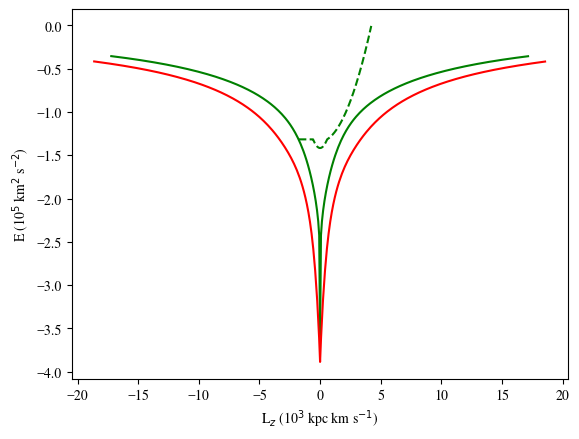

In [76]:
rs = np.arange(-100, 100, 0.5)
ps = np.column_stack((rs, rs * 0, rs * 0))

# Gala ####################################################################

vc_g = np.sqrt(-rs * pot_gala.force(ps)[:, 0])
v_g = np.column_stack((vc_g * 0, vc_g, vc_g * 0))
pv_g = np.concatenate((ps, v_g), axis=1)
lz_g = af_gala(pv_g)[:, 2]
et_g = 0.5 * np.sum(np.array(v_g) ** 2, axis=1) + pot_gala.potential(ps)

plt.plot(lz_g / lz_scale, et_g / et_scale, c="g")

lz_gb = np.arange(-10, 10, 0.01)
et_gb = []
for lz in lz_gb:
    if lz < -0.58:
        et_gb.append(-1.316)
    elif lz < 0.58:
        et_gb.append(-1.416 + 0.3 * lz**2)
    else:
        et_gb.append(-1.341 + 0.075 * lz**2)
et_gb = np.asarray(et_gb)

Rlim = pot_gala.Rcirc(E=-1.316 * et_scale)
p_lim = np.column_stack((Rlim, Rlim * 0, Rlim * 0))
vc_lim = np.sqrt(-Rlim * pot_gala.force(p_lim)[:, 0])
v_lim = np.column_stack((vc_lim * 0, vc_lim, vc_lim * 0))
pv_lim = np.concatenate((p_lim, v_lim), axis=1)
lz_lim = af_gala(pv_lim)[:, 2] / lz_scale

lz_msk = -lz_lim <= lz_gb
et_msk = et_gb <= 0

lz_gb = lz_gb[lz_msk & et_msk]
et_gb = et_gb[lz_msk & et_msk]

plt.plot(lz_gb, et_gb, c="g", ls="--")

# FIRE ####################################################################

vc_f = np.sqrt(-rs * pot_fire.force(ps)[:, 0])
v_f = np.column_stack((vc_f * 0, vc_f, vc_f * 0))
pv_f = np.concatenate((ps, v_f), axis=1)
lz_f = af_fire(pv_f)[:, 2]
et_f = 0.5 * np.sum(np.array(v_f) ** 2, axis=1) + pot_fire.potential(ps)

plt.plot(lz_f / lz_scale, et_f / et_scale, c="r")

plt.xlabel(r"L$_{z}$ (10$^3$ kpc km s$^{-1}$)")
plt.ylabel(r"E (10$^5$ km$^{2}$ s$^{-2}$)")


# Normalise

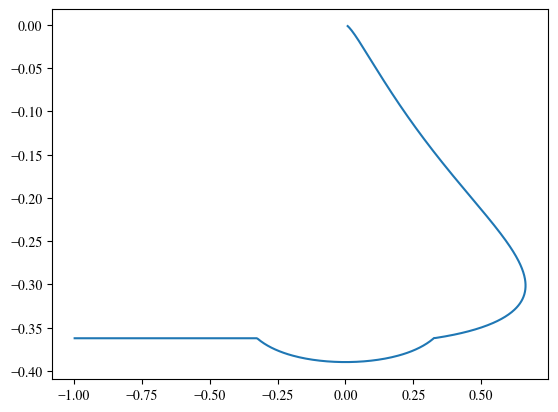

In [77]:
Rc_gb = pot_gala.Rcirc(E=(et_gb * et_scale))
pc_gb = np.column_stack((Rc_gb, Rc_gb * 0, Rc_gb * 0))
vc_gb = np.sqrt(-Rc_gb * pot_gala.force(pc_gb)[:, 0])
v_gb = np.column_stack((vc_gb * 0, vc_gb, vc_gb * 0))
pv_gb = np.concatenate((pc_gb, v_gb), axis=1)
lz_cgb = af_gala(pv_gb)[:, 2]

circ = (lz_gb * lz_scale) / lz_cgb

Et0_g = pot_gala.potential([0, 0, 0])
eps = (et_gb * et_scale) / np.abs(Et0_g)

plt.plot(circ, eps)

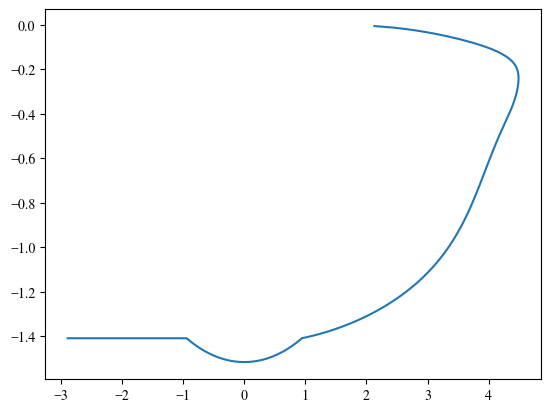

In [80]:
Et0_f = pot_fire.potential([0, 0, 0])
et_fb = (eps * np.abs(Et0_f)) / et_scale

Rc_fb = pot_fire.Rcirc(E=(et_fb * et_scale))
pc_fb = np.column_stack((Rc_fb, Rc_fb * 0, Rc_fb * 0))
vc_fb = np.sqrt(-Rc_fb * pot_fire.force(pc_fb)[:, 0])
v_fb = np.column_stack((vc_fb * 0, vc_fb, vc_fb * 0))
pv_fb = np.concatenate((pc_fb, v_fb), axis=1)
lz_cfb = af_fire(pv_fb)[:, 2]

lz_fb = (circ * lz_cfb) / lz_scale

plt.plot(lz_fb, et_fb)

Text(0, 0.5, 'E (10$^5$ km$^{2}$ s$^{-2}$)')

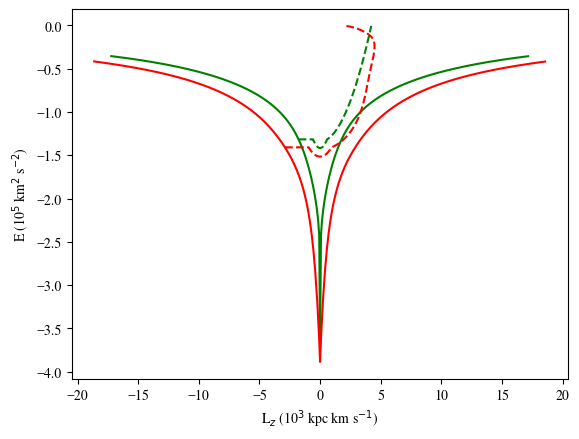

In [81]:
plt.plot(lz_g / lz_scale, et_g / et_scale, c="g")
plt.plot(lz_gb, et_gb, c="g", ls="--")

plt.plot(lz_f / lz_scale, et_f / et_scale, c="r")
plt.plot(lz_fb, et_fb, c="r", ls="--")


plt.xlabel(r"L$_{z}$ (10$^3$ kpc km s$^{-1}$)")
plt.ylabel(r"E (10$^5$ km$^{2}$ s$^{-2}$)")

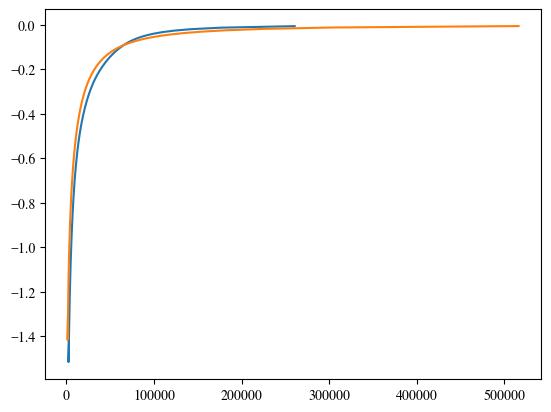

In [82]:
plt.plot(lz_cfb, et_fb)  # FIRE circular relation
plt.plot(lz_cgb, et_gb)  # gala
